# Integrating retreat, terrain and field evidence

This notebook compares Brown and Stephenson glaciers using their mapped retreat histories, geology, terrain, contemporary velocity and historical field measurements. It examines whether differences in landscape setting are consistent with their contrasting retreat patterns.

The analysis is descriptive. Observation dates, sampling footprints and coverage remain explicit, and modelled bed elevations are interpreted alongside their field validation. Fixed-elevation comparisons explore changes in the area occupying low terrain; they do not reconstruct historical glacier surfaces or measure accumulation–ablation area ratios.

## 1. Assemble the existing results

Load the exported results from the preceding notebooks and join glacier summaries using their inventory identifiers. Velocity uses the 2014 sampling footprint, while thickness summaries use the 2019 reporting footprint. Figures inherit the book’s saved style.

In [1]:
## Load the existing analysis outputs ##

from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from shapely.ops import unary_union
from IPython.display import display

import rasterio
from rasterio.mask import mask
from rasterio.features import geometry_mask
from shapely.geometry import Point, LineString
from shapely.ops import linemerge
from scipy.signal import find_peaks

project_dir = next(p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "Output_Data" / "processed").is_dir())

processed_dir = project_dir / "Output_Data" / "processed"
synthesis_dir = processed_dir / "synthesis"
figure_dir = project_dir / "Figures" / "09_Synthesis"

for folder in [synthesis_dir, figure_dir]:
    folder.mkdir(parents = True, exist_ok = True)

names = ["Brown", "Stephenson"]
years = [1947, 1988, 2014, 2019, 2026]
colours = {"Brown": "#FFB36B", "Stephenson": "#69D5FF"}

plt.rcParams.update(json.loads(
    (processed_dir / "book_figure_style.json").read_text()))


def load_table(relative_path):
    """Read a processed CSV and retain the two accepted study glaciers."""
    table = pd.read_csv(processed_dir / relative_path)
    return table.loc[table.name_1.isin(names)].copy()


def save_figure(fig, name):
    """Save a book-style figure and display it in the notebook."""
    fig.savefig(figure_dir / f"{name}.png", dpi = 200, bbox_inches = "tight")
    plt.show()


history = load_table("glacier_history/Heard_glacier_area_history.csv")
retreat = load_table("glacier_history/glacier_retreat_intervals.csv")
velocity = load_table("velocity/Heard_glacier_velocity_summary.csv")
terrain = load_table("velocity/Heard_velocity_terrain_summary.csv")
errors = load_table("velocity/Heard_velocity_error_summary.csv")
thickness = load_table(
    "geomorphology/Heard_glacier_thickness_summary_2019_mask.csv")

field_dir = processed_dir / "geomorphology/field_surveys/reconstruction"
radar = pd.read_csv(field_dir / "Brown_interpreted_bed_metrics_primary.csv")
bathy_validation = pd.read_csv(
    field_dir / "Brown_lagoon_2004_support_sensitivity.csv")

extents = gpd.read_file(
    processed_dir / "glacier_history/Heard_glacier_extents_1947_2026.gpkg")
extents = extents.loc[extents.name_1.isin(names)].to_crs(32743).copy()
extents.geometry = extents.geometry.make_valid()

assert not extents.duplicated(["RGIId", "year"]).any()
assert set(history.groupby("name_1").year.apply(
    lambda x: tuple(sorted(x)))) == {tuple(years)}

comparison = velocity.set_index("RGIId").join(
    thickness.set_index("RGIId").drop(columns = "name_1"),
    lsuffix = "_velocity", rsuffix = "_model", validate = "one_to_one")

comparison["velocity_footprint_year"] = 2014
comparison["terrain_reference_year"] = 2002
comparison["model_reporting_footprint_year"] = 2019
comparison.to_csv(synthesis_dir / "glacier_comparison.csv")

display(comparison[["name_1", "median_speed_m_yr", "coverage_percent",
    "thickness_median_m", "mask_year"]].round(2))

,name_1,median_speed_m_yr,coverage_percent,thickness_median_m,mask_year
RGIId,,,,,
RGI60-19.00005,Stephenson,281.75,91.51,116.47,2019
RGI60-19.00023,Brown,207.68,64.71,127.02,2019


### Results and interpretation

The joined records provide complementary evidence for both glaciers, although their sampling footprints differ. Velocity represents the 2014 glacier footprints, modelled thickness uses the 2019 reporting footprints, and terrain measurements reference the 2002 DEM. These are therefore comparisons of different aspects of glacier behaviour rather than simultaneous observations.

Velocity coverage is substantially higher for Stephenson (91.5%) than Brown (64.7%), which must be considered when interpreting their speed differences.

## 2. Compare retreat timing and magnitude

Compare remaining area, absolute annual loss and annual proportional loss. Proportional rates use each interval’s starting area. An additional rate normalised to the fixed 1947 area helps distinguish changes in loss magnitude from changes in the denominator.

These are interval-average area changes, not terminus velocities. Recent outlines impose no advance and retain the 2014 ice footprint above 1,000 m, so apparent stability there is not an independent observation.

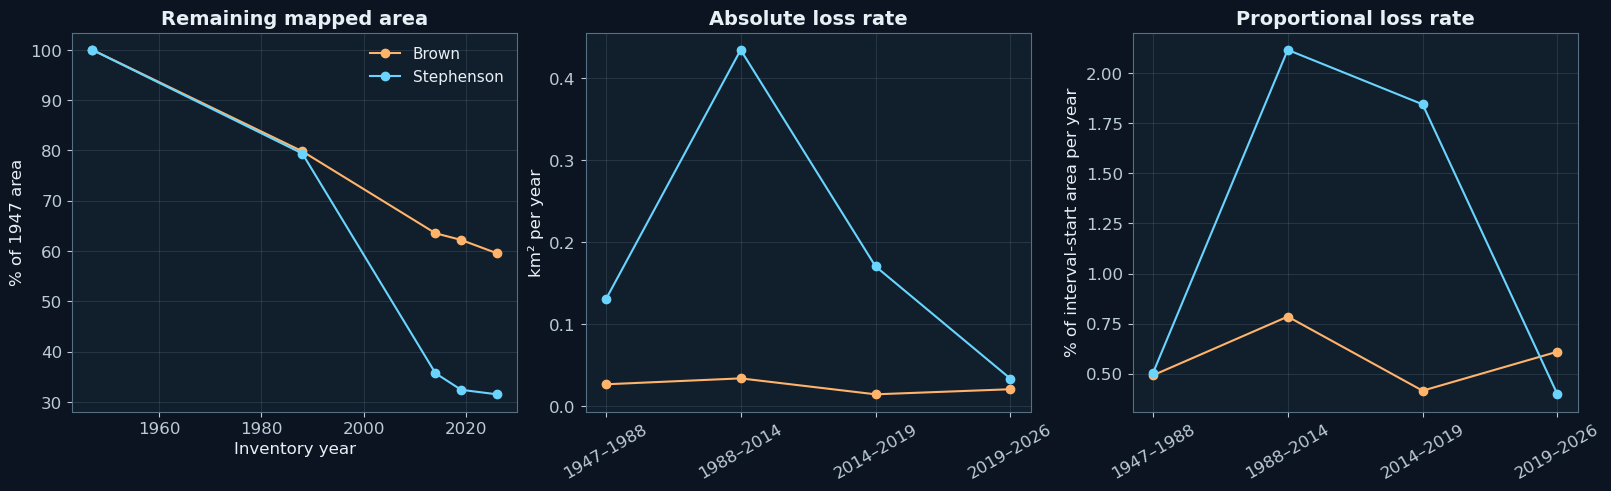

,name_1,period,area_loss_km2,area_loss_percent,annual_loss_km2,annual_loss_percent,annual_loss_pct_1947_area
22,Brown,1947–1988,1.081,20.171,0.026,0.492,0.492
4,Stephenson,1947–1988,5.325,20.605,0.130,0.503,0.503
45,Brown,1988–2014,0.873,20.415,0.034,0.785,0.627
27,Stephenson,1988–2014,11.293,55.033,0.434,2.117,1.681
68,Brown,2014–2019,0.071,2.076,0.014,0.415,0.264
50,Stephenson,2014–2019,0.851,9.225,0.170,1.845,0.659
91,Brown,2019–2026,0.142,4.270,0.020,0.610,0.380
73,Stephenson,2019–2026,0.233,2.781,0.033,0.397,0.129


In [2]:
## Compare total loss and annualised retreat ##

area = history.pivot(
    index = "year", columns = "name_1", values = "area_km2").loc[years, names]

remaining = 100 * area.div(area.loc[1947])
retreat = retreat.sort_values(["start_year", "name_1"])

retreat["annual_loss_pct_1947_area"] = [
    100 * row.annual_loss_km2 / area.loc[1947, row.name_1]
    for row in retreat.itertuples()]

periods = retreat.drop_duplicates("start_year").period.tolist()

fig, axes = plt.subplots(
    1, 3, figsize = (16, 4.8), layout = "constrained")

for name in names:
    axes[0].plot(years, remaining[name], "-o",
        color = colours[name], label = name)

    part = retreat.loc[retreat.name_1.eq(name)]
    axes[1].plot(part.period, part.annual_loss_km2, "-o",
        color = colours[name])
    axes[2].plot(part.period, part.annual_loss_percent, "-o",
        color = colours[name])

axes[0].set(title = "Remaining mapped area",
    ylabel = "% of 1947 area", xlabel = "Inventory year")
axes[1].set(title = "Absolute loss rate", ylabel = "km² per year")
axes[2].set(title = "Proportional loss rate",
    ylabel = "% of interval-start area per year")
axes[0].legend()

for ax in axes:
    ax.grid(alpha = 0.15)
for ax in axes[1:]:
    ax.tick_params(axis = "x", rotation = 30)

save_figure(fig, "01_retreat_timing")

retreat.to_csv(synthesis_dir / "retreat_comparison.csv", index = False)

display(retreat[["name_1", "period", "area_loss_km2", "area_loss_percent",
    "annual_loss_km2", "annual_loss_percent",
    "annual_loss_pct_1947_area"]].round(3))

### Results and interpretation

Both glaciers lost approximately 20% of their mapped area during 1947–1988, but their trajectories subsequently diverged. During 1988–2014, Stephenson lost 11.29 km² (55.0%), compared with Brown’s 0.87 km² (20.4%). This interval produced the greatest annualised area-loss rate for both glaciers. Brown’s largest total interval loss occurred earlier, during 1947–1988, partly reflecting that interval’s longer duration.

During 2019–2026, Brown’s proportional loss increased to 0.61% per year, while Stephenson’s declined to 0.40% per year. Stephenson nevertheless continued to lose more absolute area: 0.033 versus 0.020 km² per year. Brown also has the higher recent rate when normalised to the fixed 1947 area, so the crossover is not solely an effect of changing interval-start denominators.

These mapped differences demonstrate changing retreat behaviour, although their statistical significance has not been established against outline uncertainty.

## 3. Locate retreat within the mapped geological setting

Construct the area lost between consecutive inventories and intersect it with the geology map. Gross spatial loss and mapped gain are recorded separately; their difference gives net area loss.

Retain the source map’s classes. Moraine and other deposits describe mapped surface materials, while Snow/Ice does not identify underlying lithology. Unmapped area remains explicit. The overlay describes where retreat occurred relative to the geological map, not the material exposed at each historical date.

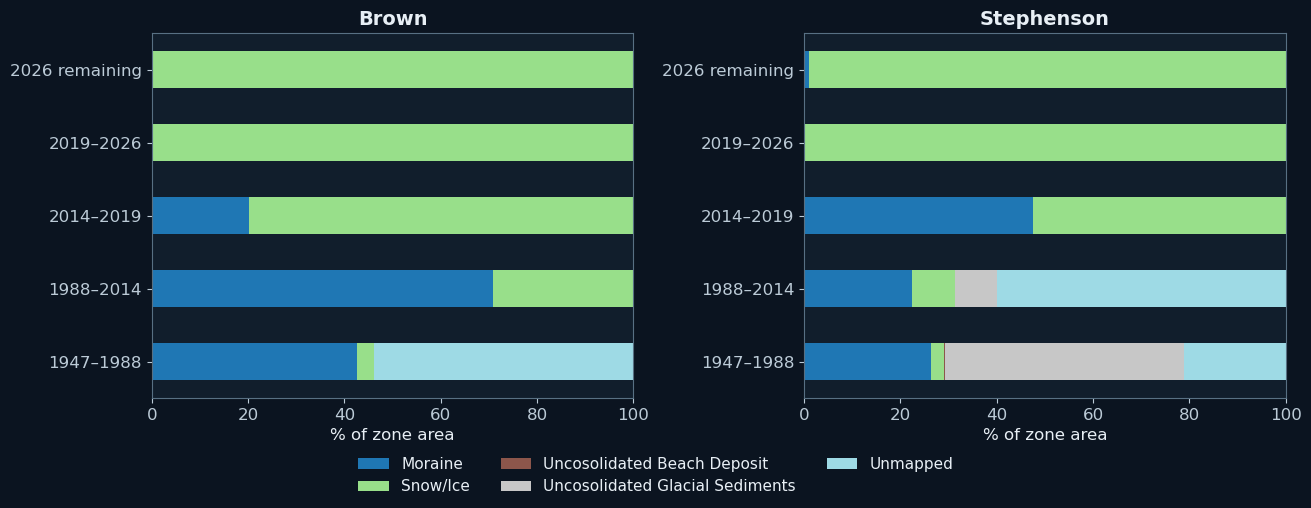

,name_1,zone,Rock_Type,area_km2,zone_percent
0,Brown,1947–1988,Moraine,0.461,42.624
1,Brown,1947–1988,Snow/Ice,0.038,3.521
2,Brown,1947–1988,Unmapped,0.582,53.856
3,Brown,1988–2014,Moraine,0.618,70.768
4,Brown,1988–2014,Snow/Ice,0.255,29.227
5,Brown,1988–2014,Unmapped,0.000,0.005
6,Brown,2014–2019,Moraine,0.014,20.188
7,Brown,2014–2019,Snow/Ice,0.056,79.812
8,Brown,2014–2019,Unmapped,0.000,0.000
9,Brown,2019–2026,Moraine,0.000,0.028


In [3]:
## Intersect mapped geology with retreat zones ##

def get_outline(name, year):
    """Return one accepted glacier outline in the project CRS."""
    return extents.loc[
        extents.name_1.eq(name) & extents.year.eq(year), "geometry"].iloc[0]


zone_rows = []
change_rows = []

for name in names:
    for start, end in zip(years[:-1], years[1:]):
        before = get_outline(name, start)
        after = get_outline(name, end)
        lost = before.difference(after)
        gained = after.difference(before)
        period = f"{start}–{end}"

        zone_rows.append(dict(
            name_1 = name, zone = period, geometry = lost))

        change_rows.append(dict(
            name_1 = name, period = period,
            gross_loss_km2 = lost.area / 1e6,
            mapped_gain_km2 = gained.area / 1e6,
            net_loss_km2 = (before.area - after.area) / 1e6))

    zone_rows.append(dict(name_1 = name, zone = "2026 remaining",
        geometry = get_outline(name, 2026)))

zones = gpd.GeoDataFrame(zone_rows, crs = extents.crs)
changes = pd.DataFrame(change_rows)

changes.to_csv(synthesis_dir / "spatial_area_changes.csv", index = False)
zones.to_file(synthesis_dir / "retreat_zones.gpkg",
    layer = "zones", driver = "GPKG")

geology = gpd.read_file(
    project_dir / "Output_Data/geology_clipped.shp").to_crs(extents.crs)
geology = geology.loc[
    geology.geometry.notna() & ~geology.geometry.is_empty].copy()
geology.geometry = geology.geometry.make_valid()
geology["Rock_Type"] = geology.Rock_Type.fillna("Unknown")

hits = gpd.overlay(zones, geology[["Rock_Type", "geometry"]],
    how = "intersection", keep_geom_type = True)
hits["area_km2"] = hits.area / 1e6

geology_rows = []

for zone in zones.itertuples():
    part = hits.loc[
        hits.name_1.eq(zone.name_1) & hits.zone.eq(zone.zone)]
    covered = unary_union(part.geometry.tolist()).area / 1e6
    overlap = part.area_km2.sum() - covered

    # Stop overlapping source classes from silently inflating percentages.
    if overlap > 0.000001:
        raise ValueError(
            f"Overlapping geology classes in {zone.name_1}, "
            f"{zone.zone}: {overlap:.6f} km²")

    amounts = part.groupby("Rock_Type").area_km2.sum().to_dict()
    zone_area = zone.geometry.area / 1e6
    amounts["Unmapped"] = max(0, zone_area - covered)

    for rock, amount in amounts.items():
        geology_rows.append(dict(
            name_1 = zone.name_1, zone = zone.zone, Rock_Type = rock,
            area_km2 = amount, zone_percent = 100 * amount / zone_area))

geology_summary = pd.DataFrame(geology_rows)
geology_summary.to_csv(
    synthesis_dir / "geology_by_retreat_zone.csv", index = False)

rock_order = sorted(geology_summary.Rock_Type.unique())
fig, axes = plt.subplots(
    1, 2, figsize = (13, 5), layout = "constrained")

for ax, name in zip(axes, names):
    part = geology_summary.loc[geology_summary.name_1.eq(name)]
    table = part.pivot(
        index = "zone", columns = "Rock_Type", values = "zone_percent")
    table = table.fillna(0).reindex(
        index = periods + ["2026 remaining"],
        columns = rock_order, fill_value = 0)

    table.plot.barh(stacked = True, ax = ax,
        colormap = "tab20", legend = False)
    ax.set(title = name, xlabel = "% of zone area",
        ylabel = "", xlim = (0, 100))

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc = "outside lower center", ncol = 3)

save_figure(fig, "02_geology_by_retreat_zone")
display(geology_summary.round(3))

### Results and interpretation

The intersected geology classes primarily describe glacial deposits and mapped Snow/Ice, providing little direct evidence about underlying bedrock. Moraine occupies 70.8% of Brown’s 1988–2014 retreat zone. Stephenson’s equivalent zone contains 22.4% moraine and 8.9% unconsolidated glacial sediments, but 59.9% is unmapped.

More than 99.9% of both glaciers’ 2019–2026 retreat zones remains classified as Snow/Ice in the geological source map. This reflects the map’s representation of those locations, rather than their surface condition after retreat. Unmapped areas likewise cannot automatically be classified as lagoon or assigned a substrate.

The overlay supports a comparison of mapped deposits and foreland setting, but cannot establish contrasting bedrock lithology or erodibility as the cause of retreat differences.

## 4. Examine changes in low-elevation area

Apply each dated outline to the same 2002 reference surface and calculate the supported area below 300, 600 and 900 m. These shared thresholds are exploratory terrain comparisons, not estimated equilibrium lines.

Using one surface isolates changes in mapped footprint relative to fixed elevations. It does not reconstruct historical surface lowering or accumulation–ablation areas. DEM coverage is reported because historical ice footprints may include areas without valid land elevations. Recent upper-area retention is also partly imposed by the 1,000 m outline constraint.

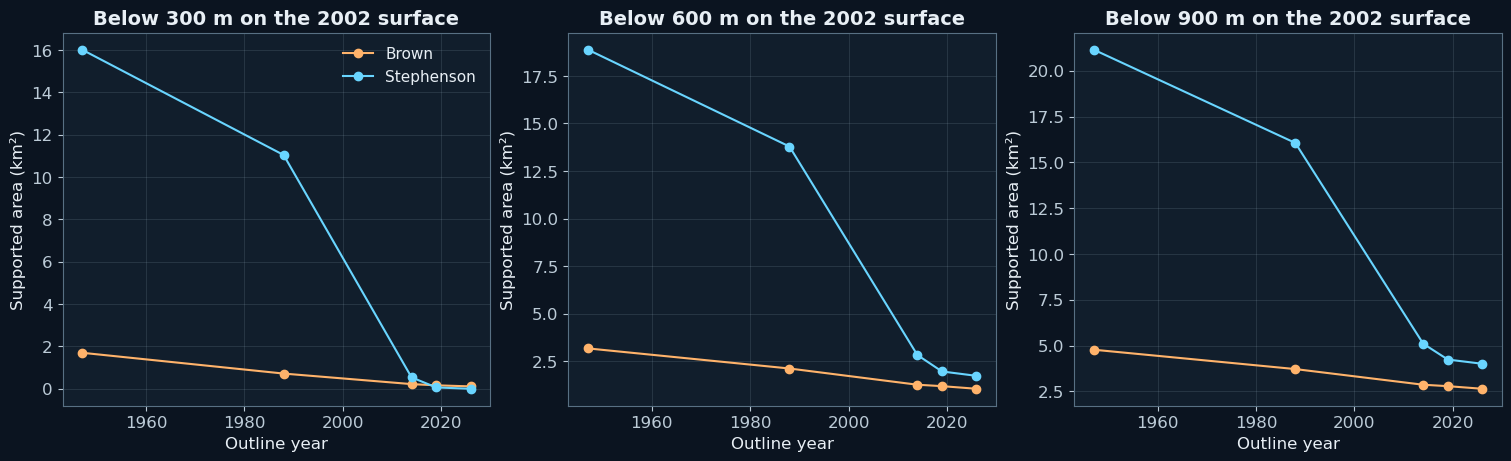

,name_1,year,threshold_m,below_threshold_km2,below_threshold_pct_supported,dem_supported_km2,dem_area_coverage_percent
0,Stephenson,1947,300,16.01,62.49,25.62,99.14
1,Stephenson,1947,600,18.88,73.69,25.62,99.14
2,Stephenson,1947,900,21.16,82.56,25.62,99.14
3,Stephenson,1988,300,11.04,53.77,20.53,100.04
4,Stephenson,1988,600,13.79,67.17,20.53,100.04
5,Stephenson,1988,900,16.06,78.24,20.53,100.04
6,Stephenson,2014,300,0.54,5.86,9.22,99.89
7,Stephenson,2014,600,2.83,30.68,9.22,99.89
8,Stephenson,2014,900,5.10,55.33,9.22,99.89
9,Stephenson,2019,300,0.06,0.75,8.35,99.63


In [4]:
## Compare low-elevation area using one fixed reference surface ##


reference_path = (
    processed_dir / "geomorphology/Heard_surface_DEM_2002_50m.tif")

thresholds = [300, 600, 900]
low_rows = []

if reference_path.exists():
    with rasterio.open(reference_path) as src:
        pixel_km2 = abs(
            src.transform.a * src.transform.e
            - src.transform.b * src.transform.d) / 1e6

        for row in extents.to_crs(src.crs).itertuples():
            data, _ = mask(src, [row.geometry],
                crop = True, filled = False, indexes = 1)

            values = data.compressed()
            values = values[np.isfinite(values)]
            supported_area = len(values) * pixel_km2

            for threshold in thresholds:
                low_area = (
                    np.count_nonzero(values < threshold) * pixel_km2
                    if len(values) else np.nan)

                low_rows.append(dict(
                    name_1 = row.name_1,
                    year = row.year,
                    threshold_m = threshold,
                    below_threshold_km2 = low_area,
                    below_threshold_pct_supported = (
                        100 * low_area / supported_area
                        if supported_area else np.nan),
                    dem_supported_km2 = supported_area,
                    dem_area_coverage_percent = (
                        100 * supported_area / row.geometry.area * 1e6)))

    low_area_history = pd.DataFrame(low_rows)
    low_area_history.to_csv(
        synthesis_dir / "fixed_surface_low_elevation_area.csv",
        index = False)

    fig, axes = plt.subplots(
        1, 3, figsize = (15, 4.5), layout = "constrained")

    for ax, threshold in zip(axes, thresholds):
        for name in names:
            part = low_area_history.loc[
                low_area_history.name_1.eq(name)
                & low_area_history.threshold_m.eq(threshold)
            ].sort_values("year")

            ax.plot(part.year, part.below_threshold_km2, "-o",
                color = colours[name], label = name)

        ax.set(title = f"Below {threshold} m on the 2002 surface",
            xlabel = "Outline year", ylabel = "Supported area (km²)")
        ax.grid(alpha = 0.15)

    axes[0].legend()
    save_figure(fig, "03_low_elevation_area")
    display(low_area_history.round(2))

else:
    low_area_history = pd.DataFrame()
    print(f"Run this cell locally with the existing raster: {reference_path}")

### Results and interpretation

Stephenson’s historical footprint occupied substantially more low-elevation terrain. On the fixed 2002 reference surface, its area below 300 m decreased from 16.01 km² within the 1947 outline to 11.04 km² in 1988 and 0.54 km² in 2014. No sampled cells below this threshold remain within its 2026 outline. Brown’s corresponding area declined from 1.70 to 0.72, 0.22 and 0.11 km², with its largest interval reduction occurring during 1947–1988.

The broader contraction persists at the 600 and 900 m thresholds. By 2026, 21.4% of Stephenson’s DEM-supported footprint lies below 600 m, compared with 33.0% of Brown’s. This is consistent with Stephenson having already lost much of its extensive low-elevation tongue, providing a plausible contribution to its reduced recent area-loss rate.

DEM coverage is approximately complete. Small values above 100% arise from comparing whole raster-cell areas with vector polygon areas. These results describe changing footprints on one reference surface; they do not reconstruct historical elevations or establish that accumulation now exceeds ablation. Recent retention of higher ice is also partly imposed by the outline method.

## 5. Geomorphological controls on retreat and flow

This section investigates whether bed geometry, mapped ice-corridor width and
surface exposure help explain the contrasting behaviour of Brown and Stephenson.

Fixed transects connect the former lower tongues with the surviving glaciers.
Distances increase inland. These are analysis transects, not reconstructed
historical flowlines; Stephenson's route follows its surviving northern tongue.
The locator maps document their positions.

The candidate bed combines a 2002 surface with newer modelled thickness.
Its features are therefore treated as hypotheses to investigate, rather than
measured subglacial landforms.

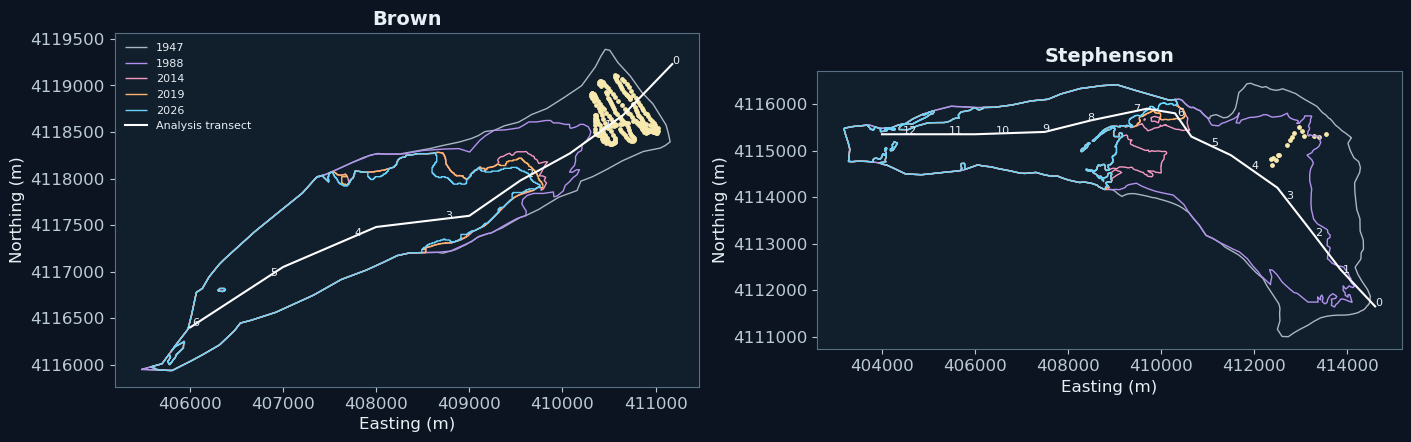

In [5]:
## Set up the geomorphological transects ##

terrain_full = terrain.loc[terrain.support.eq('2014 footprint')].copy()
geom_dir = processed_dir / 'geomorphology'
map_dir = processed_dir / 'interactive_map_data'
soundings = gpd.read_file(map_dir / 'lagoon_soundings_2004.geojson').to_crs(extents.crs)
velocity_layers = json.loads((map_dir / 'velocity_layers.json').read_text())['glaciers']
field_metadata = json.loads((field_dir / 'field_reconstruction_metadata.json').read_text())

settings = dict(step_m = 50, offsets_m = [-100, -50, 0, 50, 100],
    crest_prominence_m = 10, crest_spacing_m = 300, crest_match_m = 150,
    perturbation_wavelength_m = 1000, assumed_water_level_m = 0.0)

raster_paths = dict(surface = geom_dir / 'Heard_surface_DEM_2002_50m.tif',
    bed = geom_dir / 'Heard_bed_estimate_candidate_50m.tif',
    error = geom_dir / 'Heard_Millan_thickness_error_land_50m.tif')
bathy_path = field_dir / 'Brown_lagoon_2004_depth.tif'

# EPSG:32743 coordinates, ordered from seaward to inland.
transect_vertices = {
    'Brown': [(411180, 4119230), (410650, 4118680), (410080, 4118270),
        (409550, 4117980), (409000, 4117600), (408000, 4117480),
        (407000, 4117050), (406000, 4116400)],
    'Stephenson': [(414600, 4111650), (413850, 4112450), (413200, 4113300),
        (412500, 4114200), (411500, 4114900), (410650, 4115300),
        (410300, 4115800), (409700, 4115900), (408500, 4115650),
        (407500, 4115400), (406000, 4115350), (404000, 4115350)]}
transects = {name: LineString(xy) for name, xy in transect_vertices.items()}


def project_path(value):
    """Resolve a saved project-relative path on Windows or Linux."""
    return project_dir / value.replace('\\', '/')


def line_parts(geometry):
    """Extract non-empty line components from an intersection."""
    if geometry.is_empty:
        return []
    if geometry.geom_type == 'LineString':
        return [geometry]
    return [part for child in getattr(geometry, 'geoms', []) for part in line_parts(child)]


def transect_xy(line, distances, offsets):
    """Return coordinates at signed offsets normal to a seaward-to-inland line."""
    distances = np.asarray(distances)
    centre = np.array([line.interpolate(float(s)).coords[0] for s in distances])
    before = np.array([line.interpolate(max(0, float(s) - 25)).coords[0] for s in distances])
    after = np.array([line.interpolate(min(line.length, float(s) + 25)).coords[0] for s in distances])
    tangent = after - before
    tangent /= np.linalg.norm(tangent, axis = 1)[:, None]
    normal = np.column_stack([-tangent[:, 1], tangent[:, 0]])
    return centre[:, None, :] + normal[:, None, :] * np.asarray(offsets)[None, :, None]


def sample_raster(path, xy, polygon = None):
    """Sample native cells; return values and cell IDs without filling NoData."""
    shape = xy.shape[:-1]
    coordinates = xy.reshape(-1, 2)
    with rasterio.open(path) as src:
        if src.crs != extents.crs:
            raise ValueError(f'Unexpected CRS: {path}')
        values = np.ma.vstack(list(src.sample(coordinates, indexes = 1, masked = True)))
        values = values.astype(float).filled(np.nan).ravel()
        rr, cc = rasterio.transform.rowcol(src.transform, *coordinates.T)
        ids = np.asarray(rr, dtype = np.int64) * src.width + np.asarray(cc)
    if polygon is not None:
        values[[not polygon.covers(Point(p)) for p in coordinates]] = np.nan
    values[~np.isfinite(values)] = np.nan
    return values.reshape(shape), ids.reshape(shape)


def swath_median(values, ids, require_centre = True):
    """Summarise unique native cells at each station, retaining centreline gaps."""
    medians, counts = [], []
    for row, cells in zip(values, ids):
        valid = np.isfinite(row)
        unique = np.unique(cells[valid], return_index = True)[1]
        samples = row[valid][unique]
        supported = len(samples) and (not require_centre or np.isfinite(row[len(row) // 2]))
        medians.append(float(np.median(samples)) if supported else np.nan)
        counts.append(len(samples))
    return np.asarray(medians), np.asarray(counts)


def smooth_profile(values, window = 3):
    """Use a full-window median so smoothing cannot bridge missing stations."""
    return pd.Series(values).rolling(window, center = True, min_periods = window).median().to_numpy()


def crest_indices(values):
    """Screen local highs within continuous support; thresholds are descriptive."""
    valid = np.flatnonzero(np.isfinite(values))
    blocks = np.split(valid, np.flatnonzero(np.diff(valid) > 1) + 1)
    peaks = []
    for block in blocks:
        if len(block) >= 5:
            found, _ = find_peaks(values[block], prominence = settings['crest_prominence_m'],
                distance = max(1, int(settings['crest_spacing_m'] / settings['step_m'])))
            peaks.extend(block[found])
    return np.asarray(peaks, dtype = int)


required = list(raster_paths.values()) + [bathy_path]
for name in names:
    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    required.append(project_path(velocity_layers[rgi]['layers']['median_speed']))
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Missing local outputs:\n' + '\n'.join(missing))

gpd.GeoDataFrame({'name_1': names, 'direction': ['seaward to inland'] * 2,
    'geometry': [transects[name] for name in names]}, crs = extents.crs).to_file(
    synthesis_dir / 'geomorphology_transects.gpkg', layer = 'transects', driver = 'GPKG')

fig, axes = plt.subplots(1, 2, figsize = (14, 6), layout = 'constrained')
for ax, name in zip(axes, names):
    for year, colour in zip(years, ['#AAB4C3', '#B292EE', '#F49AC2', '#FFB36B', '#69D5FF']):
        extents.loc[extents.name_1.eq(name) & extents.year.eq(year)].boundary.plot(
            ax = ax, color = colour, linewidth = 1, label = str(year))
    line = transects[name]
    ax.plot(*line.xy, color = 'white', linewidth = 1.5, label = 'Analysis transect')
    soundings.loc[soundings.name_1.eq(name)].plot(ax = ax, color = '#F8E9AE', markersize = 6)
    for s in np.arange(0, line.length, 1000):
        p = line.interpolate(s)
        ax.text(p.x, p.y, f'{s / 1000:.0f}', fontsize = 8)
    ax.set(title = name, aspect = 'equal', xlabel = 'Easting (m)', ylabel = 'Northing (m)')
    ax.ticklabel_format(style = 'plain', useOffset = False)
axes[0].legend(fontsize = 8)
save_figure(fig, '04a_transect_locations')

**Results / interpretation — pending:** Describe which parts of each former
and surviving glacier the transects represent.

### 5. Bed geometry, flow and retreat along the transects

Raster values are sampled at 50 m stations using five positions across a
200 m swath. Repeated samples from the same raster cell are counted once.
Missing centreline values remain gaps. Sampling at 50 m does not increase the
resolution of the 120 m velocity data.

Candidate bed values are restricted to the 2019 glacier footprint. A
three-station median highlights broad features, and its signed gradient
distinguishes beds rising inland from beds deepening inland.

Historical fronts are defined by the seaward end of the transect segment
connected to its inland endpoint. Detached segments are excluded. Widths
describe the connected mapped ice corridor, not surveyed bedrock valley width.

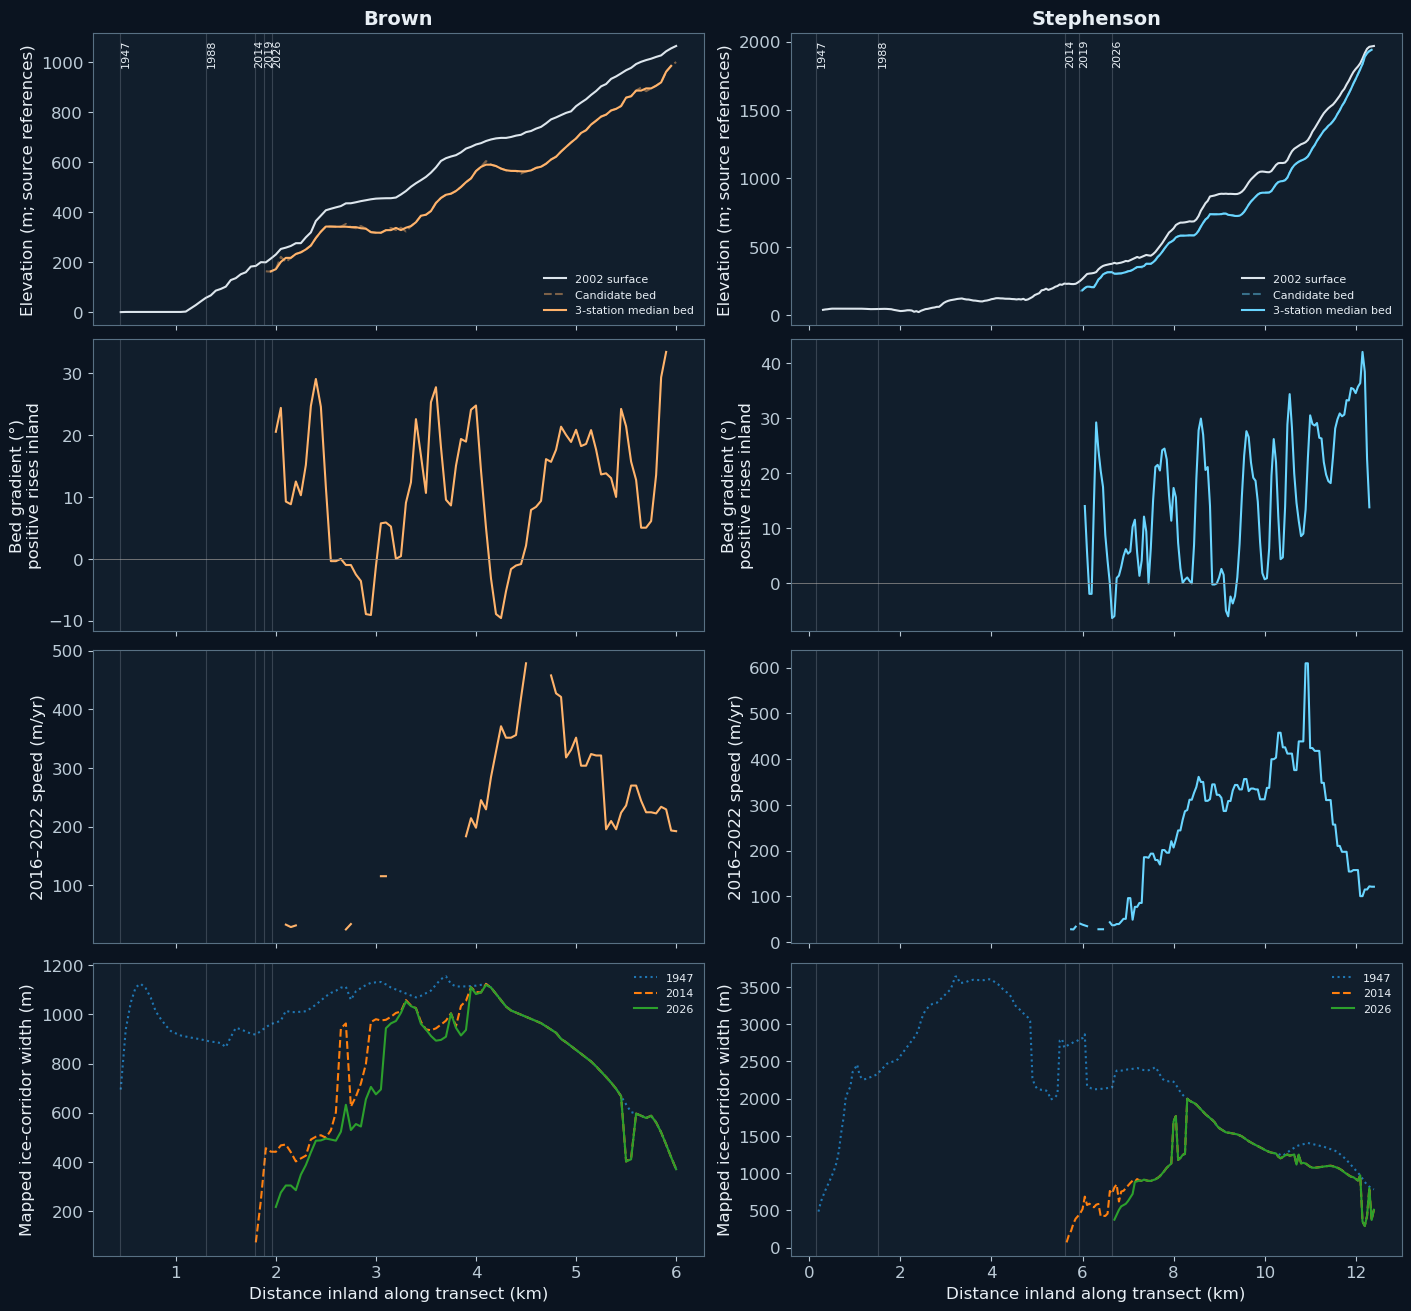

,name_1,start_year,end_year,transect_retreat_m,transect_retreat_m_yr
0,Brown,1947,1988,859.70,20.97
1,Brown,1988,2014,481.05,18.50
2,Brown,2014,2019,95.46,19.09
3,Brown,2019,2026,83.33,11.90
4,Stephenson,1947,1988,1357.93,33.12
5,Stephenson,1988,2014,4109.80,158.07
6,Stephenson,2014,2019,306.55,61.31
7,Stephenson,2019,2026,724.34,103.48


In [6]:
## Sample bed geometry, contemporary flow and mapped corridor width ##

def corridor_width(line, station, polygon):
    """Measure the connected polygon width through a station, not bedrock valley width."""
    xy = transect_xy(line, [station], [-4000, 0, 4000])[0]
    cross = LineString([xy[0], xy[2]])
    centre = Point(xy[1])
    pieces = line_parts(cross.intersection(polygon))
    pieces = line_parts(linemerge(pieces)) if len(pieces) > 1 else pieces
    selected = [p for p in pieces if p.distance(centre) < 0.01]
    if not selected:
        return np.nan
    piece = max(selected, key = lambda p: p.length)
    return piece.length if piece.length < cross.length - 1 else np.nan


profiles, profile_swaths = {}, {}
terminus_rows = []

for name in names:
    line = transects[name]
    stations = np.arange(0, line.length, settings['step_m'])
    xy = transect_xy(line, stations, settings['offsets_m'])
    p = pd.DataFrame({'name_1': name, 'distance_m': stations,
        'E': xy[:, 2, 0], 'N': xy[:, 2, 1]})

    for layer, path in raster_paths.items():
        footprint = get_outline(name, 2019) if layer in ['bed', 'error'] else None
        values, ids = sample_raster(path, xy, footprint)
        p[layer + '_m'], p[layer + '_cells'] = swath_median(values, ids)
        if layer == 'bed':
            profile_swaths[name] = values

    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    values, ids = sample_raster(project_path(velocity_layers[rgi]['layers']['median_speed']),
        xy, get_outline(name, 2014))
    p['speed_m_yr'], p['speed_cells'] = swath_median(values, ids)
    p['bed_smooth_m'] = smooth_profile(p.bed_m.to_numpy())
    p['bed_gradient_deg'] = np.degrees(np.arctan(np.gradient(p.bed_smooth_m, settings['step_m'])))
    p.loc[p.bed_smooth_m.isna(), 'bed_gradient_deg'] = np.nan

    for year in [1947, 2014, 2026]:
        p[f'width_{year}_m'] = [corridor_width(line, s, get_outline(name, year)) for s in stations]
    profiles[name] = p

    for year in years:
        pieces = line_parts(line.intersection(get_outline(name, year)))
        pieces = line_parts(linemerge(pieces)) if len(pieces) > 1 else pieces
        connected = [part for part in pieces if part.distance(Point(line.coords[-1])) < 0.01]
        front = min(line.project(Point(c)) for c in connected[0].coords) if len(connected) == 1 else np.nan
        terminus_rows.append(dict(name_1 = name, year = year, front_distance_m = front,
            intersected_segments = len(pieces), definition = 'start of inland-connected transect segment'))

profile_table = pd.concat(profiles.values(), ignore_index = True)
termini = pd.DataFrame(terminus_rows).sort_values(['name_1', 'year'])
rate_rows = []

for name, part in termini.groupby('name_1', sort = False):
    for before, after in zip(list(part.itertuples())[:-1], list(part.itertuples())[1:]):
        rate_rows.append(dict(name_1 = name, start_year = before.year, end_year = after.year,
            transect_retreat_m = after.front_distance_m - before.front_distance_m,
            transect_retreat_m_yr = (after.front_distance_m - before.front_distance_m) / (after.year - before.year)))

transect_retreat = pd.DataFrame(rate_rows)
profile_table.to_csv(synthesis_dir / 'geomorphology_profiles.csv', index = False)
termini.to_csv(synthesis_dir / 'transect_termini.csv', index = False)
transect_retreat.to_csv(synthesis_dir / 'transect_retreat_rates.csv', index = False)

fig, axes = plt.subplots(4, 2, figsize = (14, 13), sharex = 'col', layout = 'constrained')
for j, name in enumerate(names):
    p = profiles[name]
    x = p.distance_m / 1000

    axes[0, j].plot(x, p.surface_m, color = '#DDE6ED', label = '2002 surface')
    axes[0, j].plot(x, p.bed_m, '--', color = colours[name], alpha = 0.45, label = 'Candidate bed')
    axes[0, j].plot(x, p.bed_smooth_m, color = colours[name], label = '3-station median bed')
    axes[0, j].set(title = name, ylabel = 'Elevation (m; source references)')

    axes[1, j].plot(x, p.bed_gradient_deg, color = colours[name])
    axes[1, j].axhline(0, color = 'grey', linewidth = 0.6)
    axes[1, j].set(ylabel = 'Bed gradient (°)\npositive rises inland')

    axes[2, j].plot(x, p.speed_m_yr, color = colours[name])
    axes[2, j].set(ylabel = '2016–2022 speed (m/yr)')

    for year, style in [(1947, ':'), (2014, '--'), (2026, '-')]:
        axes[3, j].plot(x, p[f'width_{year}_m'], style, label = str(year))
    axes[3, j].set(ylabel = 'Mapped ice-corridor width (m)',
        xlabel = 'Distance inland along transect (km)')

    for row in termini.loc[termini.name_1.eq(name)].itertuples():
        if np.isfinite(row.front_distance_m):
            for ax in axes[:, j]:
                ax.axvline(row.front_distance_m / 1000, color = '#AAB4C3', alpha = 0.25, linewidth = 0.8)
            axes[0, j].text(row.front_distance_m / 1000, 0.98, str(row.year), rotation = 90,
                transform = axes[0, j].get_xaxis_transform(), va = 'top', fontsize = 8)
    axes[0, j].legend(fontsize = 8)
    axes[3, j].legend(fontsize = 8)

save_figure(fig, '04b_geometry_flow_profiles')
display(transect_retreat.round(2))

**Results / interpretation — pending:** Identify major bed-gradient changes,
narrowing sections and velocity transitions. Compare their locations with
dated fronts and interval retreat rates. Distinguish transect retreat from
whole-glacier area loss and contemporary speed from historical retreat.



### Candidate bed highs and sensitivity

Local highs are screened using a minimum prominence of 10 m and separation
of 300 m. These are descriptive selection thresholds, not proof of pinning.

Each candidate is checked against wider smoothing, profiles displaced
100 m to either side, and four spatially coherent thickness perturbations.
The perturbations use the supplied thickness-error magnitude with a 1 km
wavelength. They test sensitivity to bed shape; they are not a calibrated
error ensemble or confidence interval.

A candidate persists in a trial if a local high remains within 150 m.
Unsupported trials are left unclassified. Because the thickness model uses
velocity, correspondence between candidate bed geometry and flow is not
independent validation.

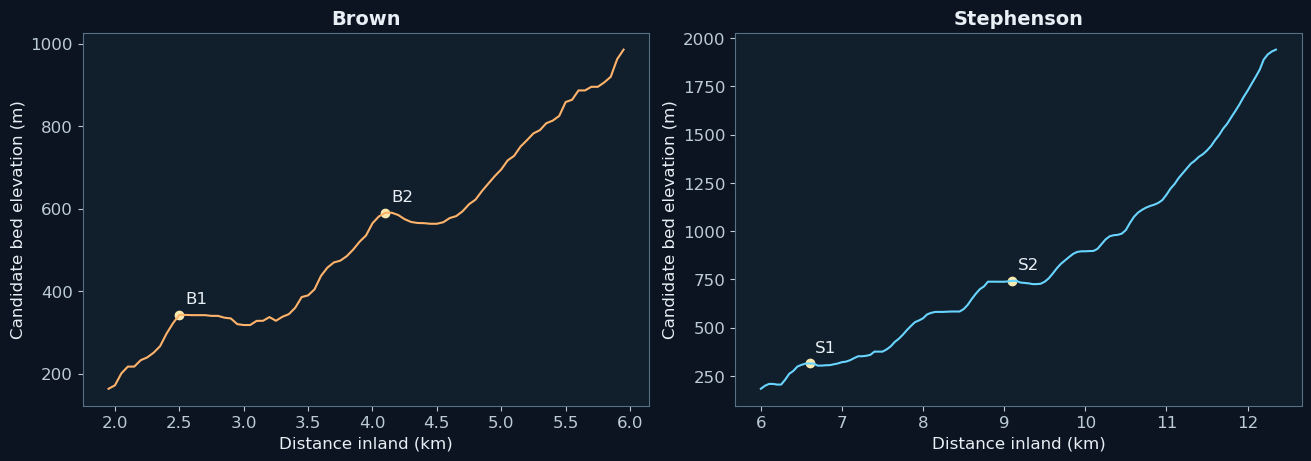

,name_1,candidate,distance_m,E,N,candidate_bed_m,reported_thickness_error_m,speed_m_yr,wider_smoothing,offset_minus_100m,offset_plus_100m,error_phase_0.00,error_phase_1.57,error_phase_3.14,error_phase_4.71,supported_trials,trials_with_nearby_high
0,Brown,B1,2500.0,409196.31,4117735.63,342.60,40.0,NaN,True,True,False,False,True,True,False,7,4
1,Brown,B2,4100.0,407674.59,4117340.07,590.13,40.0,229.59,True,True,False,True,False,True,True,7,5
2,Stephenson,S1,6600.0,409784.32,4115885.95,314.96,40.0,43.05,False,True,None,True,True,True,False,6,4
3,Stephenson,S2,9100.0,407342.11,4115394.74,742.92,47.0,286.50,True,False,False,False,False,True,True,7,3


In [7]:
## Screen candidate bed highs and test their persistence ##

candidate_rows = []

for name in names:
    p = profiles[name]
    x = p.distance_m.to_numpy()
    variants = {'wider_smoothing': smooth_profile(p.bed_m.to_numpy(), 5),
        'offset_minus_100m': smooth_profile(profile_swaths[name][:, 0]),
        'offset_plus_100m': smooth_profile(profile_swaths[name][:, -1])}

    # Deterministic shape tests, not probabilistic error realisations.
    for phase in np.arange(4) * np.pi / 2:
        delta = p.error_m.to_numpy() * np.sin(
            2 * np.pi * x / settings['perturbation_wavelength_m'] + phase)
        trial = np.minimum(p.surface_m.to_numpy(), p.bed_m.to_numpy() - delta)
        variants[f'error_phase_{phase:.2f}'] = smooth_profile(trial)

    base = p.bed_smooth_m.to_numpy()
    for number, index in enumerate(crest_indices(base), 1):
        row = dict(name_1 = name, candidate = f'{name[0]}{number}', distance_m = x[index],
            E = p.E.iloc[index], N = p.N.iloc[index], candidate_bed_m = base[index],
            reported_thickness_error_m = p.error_m.iloc[index], speed_m_yr = p.speed_m_yr.iloc[index])
        for label, trial in variants.items():
            nearby = np.abs(x - x[index]) <= settings['crest_match_m']
            supported = np.isfinite(trial[nearby]).all()
            peaks = crest_indices(trial)
            row[label] = (bool(np.any(np.abs(x[peaks] - x[index]) <= settings['crest_match_m']))
                if supported else None)
        tested = [row[label] for label in variants if row[label] is not None]
        row['supported_trials'] = len(tested)
        row['trials_with_nearby_high'] = sum(tested)
        candidate_rows.append(row)

candidates = pd.DataFrame(candidate_rows, columns = ['name_1', 'candidate', 'distance_m', 'E', 'N',
    'candidate_bed_m', 'reported_thickness_error_m', 'speed_m_yr', *variants,
    'supported_trials', 'trials_with_nearby_high'])
candidates.to_csv(synthesis_dir / 'candidate_bed_highs.csv', index = False)

fig, axes = plt.subplots(1, 2, figsize = (13, 4.5), layout = 'constrained')
for ax, name in zip(axes, names):
    p = profiles[name]
    ax.plot(p.distance_m / 1000, p.bed_smooth_m, color = colours[name])
    for row in candidates.loc[candidates.name_1.eq(name)].itertuples():
        ax.scatter(row.distance_m / 1000, row.candidate_bed_m, color = '#F8E9AE')
        ax.annotate(row.candidate, (row.distance_m / 1000, row.candidate_bed_m),
            xytext = (4, 8), textcoords = 'offset points')
    ax.set(title = name, xlabel = 'Distance inland (km)', ylabel = 'Candidate bed elevation (m)')

save_figure(fig, '04c_candidate_bed_highs')
display(candidates.round(2) if len(candidates) else pd.DataFrame({
    'result': ['No local highs met the screening criteria.']}))

**Results / interpretation — pending:** Identify which candidate highs persist
across supported trials and which depend strongly on smoothing, sampling
position or thickness assumptions. No detected high is automatically a
pinning point, and an empty result does not establish a featureless bed.

### Cross-sectional geometry

Cross-sections are extracted 250 m inland of the 2026 transect front and at
up to two candidate highs. Where insufficient candidates exist, additional
sections provide context along the supported bed profile.

These sections compare the 2002 surface with the candidate bed inside the
2019 footprint. Their different source dates preclude treating the shaded
or vertical separation as contemporary measured ice thickness.

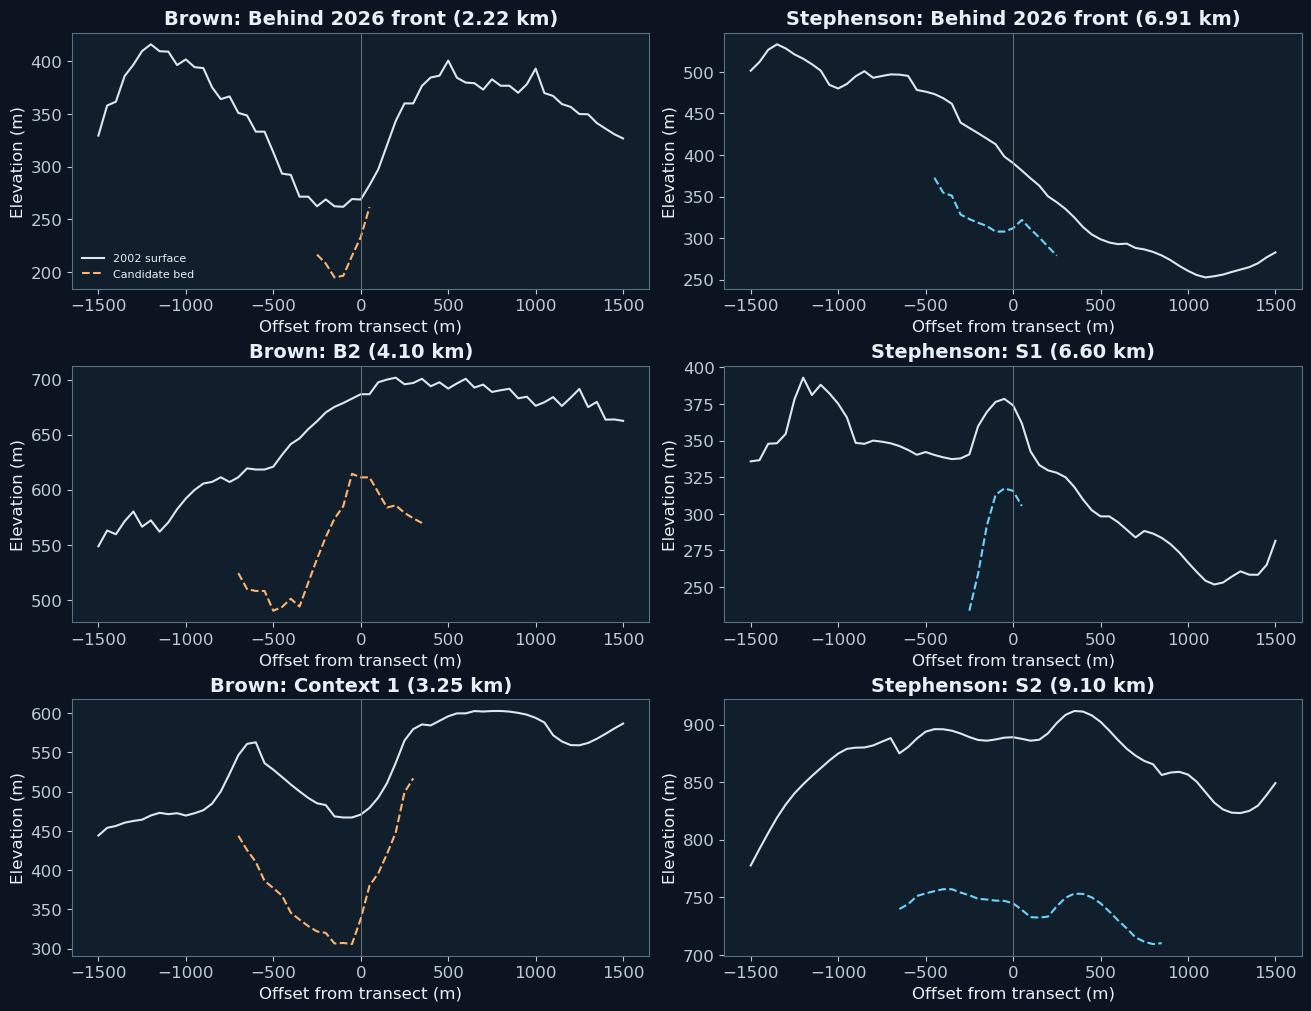

In [8]:
## Inspect glacier cross-sections at candidate controls and the recent front ##

glacier_sections = []
fig, axes = plt.subplots(3, 2, figsize = (13, 10), layout = 'constrained')

for column, name in enumerate(names):
    line, p = transects[name], profiles[name]
    front = termini.loc[termini.name_1.eq(name) & termini.year.eq(2026), 'front_distance_m'].iloc[0]
    selected = [('Behind 2026 front', min(line.length - 100, front + 250))]
    ranked = candidates.loc[candidates.name_1.eq(name)].sort_values(
        'trials_with_nearby_high', ascending = False)
    options = [(row.candidate, row.distance_m) for row in ranked.itertuples()]
    supported_stations = p.loc[p.bed_m.notna(), 'distance_m']

    if len(supported_stations):
        options += [(f'Context {i + 1}', s)
            for i, s in enumerate(supported_stations.quantile([0.33, 0.67]))]
    for label, station in options:
        if len(selected) < 3 and all(abs(station - s) >= 300 for _, s in selected):
            selected.append((label, station))

    for row_number, ax in enumerate(axes[:, column]):
        if row_number >= len(selected):
            ax.set_visible(False)
            continue
        label, station = selected[row_number]
        offsets = np.arange(-1500, 1501, 50)
        xy = transect_xy(line, [station], offsets)[0]
        surface_values, _ = sample_raster(raster_paths['surface'], xy)
        bed_values, _ = sample_raster(raster_paths['bed'], xy, get_outline(name, 2019))
        glacier_sections.append(pd.DataFrame({'name_1': name, 'section': label, 'distance_m': station,
            'offset_m': offsets, 'E': xy[:, 0], 'N': xy[:, 1],
            'surface_m': surface_values, 'bed_m': bed_values}))
        ax.plot(offsets, surface_values, color = '#DDE6ED', label = '2002 surface')
        ax.plot(offsets, bed_values, '--', color = colours[name], label = 'Candidate bed')
        ax.axvline(0, color = 'grey', linewidth = 0.6)
        ax.set(title = f'{name}: {label} ({station / 1000:.2f} km)',
            xlabel = 'Offset from transect (m)', ylabel = 'Elevation (m)')

axes[0, 0].legend(fontsize = 8)
glacier_cross_sections = pd.concat(glacier_sections, ignore_index = True)
glacier_cross_sections.to_csv(synthesis_dir / 'glacier_cross_sections.csv', index = False)
save_figure(fig, '04d_glacier_cross_sections')

**Results / interpretation — pending:** Describe cross-sectional relief and
whether the candidate highs resemble broader transverse features or isolated
profile irregularities. Relate the sections to mapped corridor widths.

### Surface orientation and potential summer exposure

An orientation index compares direct solar incidence on the glacier surface
with a horizontal surface at the same latitude. It samples representative
days in November–February and integrates over daylight.

The calculation uses existing surface slope and aspect aggregated to 120 m.
Cells with strongly mixed aspects are excluded, while nearly flat cells
receive an index of one. Both the full 2014 footprint and its portion below
600 m are summarised.

This is a geometric exposure index, not a melt or radiation-budget model.
It excludes terrain-horizon shading, atmospheric attenuation, cloud, albedo
and debris thickness. It does not quantify wind-driven snow redistribution.

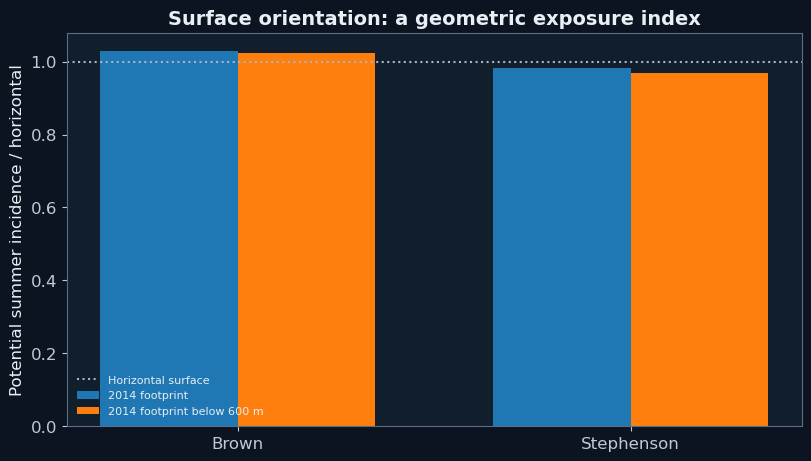

,name_1,support,supported_cells,support_percent,median_slope_deg,median_summer_incidence
0,Brown,2014 footprint,234,98.319,13.099,1.028
1,Brown,2014 footprint below 600 m,88,98.876,15.614,1.024
2,Stephenson,2014 footprint,614,96.541,16.913,0.983
3,Stephenson,2014 footprint below 600 m,186,96.875,14.247,0.968


In [9]:
## Compare surface exposure using summer solar geometry ##

def summer_incidence(slope_deg, aspect_deg, latitude_deg = -53.1):
    """Direct-beam incidence relative to a horizontal surface; no cloud or horizon shading."""
    slope = np.radians(slope_deg)
    aspect = np.radians(aspect_deg)
    east = np.sin(slope) * np.sin(aspect)
    north = np.sin(slope) * np.cos(aspect)
    up = np.cos(slope)
    latitude = np.radians(latitude_deg)
    received = np.zeros_like(slope, dtype = float)
    horizontal = 0.0

    for day in [319, 349, 15, 46]:
        declination = np.radians(23.44) * np.sin(2 * np.pi * (284 + day) / 365)
        for hour_angle in np.radians(np.arange(-172.5, 180, 15)):
            sun_e = -np.cos(declination) * np.sin(hour_angle)
            sun_n = (np.cos(latitude) * np.sin(declination)
                - np.sin(latitude) * np.cos(declination) * np.cos(hour_angle))
            sun_u = (np.sin(latitude) * np.sin(declination)
                + np.cos(latitude) * np.cos(declination) * np.cos(hour_angle))
            if sun_u > 0:
                received += np.maximum(0, east * sun_e + north * sun_n + up * sun_u)
                horizontal += sun_u
    return received / horizontal


exposure_rows = []

for name in names:
    rgi = velocity.loc[velocity.name_1.eq(name), 'RGIId'].iloc[0]
    layers = velocity_layers[rgi]['layers']
    arrays = {}

    for key in ['surface_slope_120m', 'surface_aspect_120m',
            'surface_aspect_strength_120m', 'dem_120m']:
        with rasterio.open(project_path(layers[key])) as src:
            arrays[key] = src.read(1, masked = True).astype(float).filled(np.nan)
            grid = (src.crs, src.transform, src.shape)
            if key == 'surface_slope_120m':
                reference_grid, output_profile = grid, src.profile.copy()
            elif grid != reference_grid:
                raise ValueError(f'Exposure grids differ for {name}.')

    slope = arrays['surface_slope_120m']
    aspect = arrays['surface_aspect_120m'].copy()
    flat = np.isfinite(slope) & (slope <= 1)
    aspect[flat] = 0
    inside = geometry_mask([get_outline(name, 2014)], out_shape = slope.shape,
        transform = reference_grid[1], invert = True)
    valid = inside & np.isfinite(slope) & np.isfinite(aspect) & (
        flat | (arrays['surface_aspect_strength_120m'] >= 0.5))
    incidence = np.where(valid, summer_incidence(slope, aspect), np.nan)
    incidence[flat & valid] = 1.0

    for label, footprint in [('2014 footprint', inside),
            ('2014 footprint below 600 m', inside & (arrays['dem_120m'] < 600))]:
        keep = footprint & valid
        exposure_rows.append(dict(name_1 = name, support = label, supported_cells = int(keep.sum()),
            support_percent = 100 * keep.sum() / footprint.sum() if footprint.any() else np.nan,
            median_slope_deg = float(np.median(slope[keep])) if keep.any() else np.nan,
            median_summer_incidence = float(np.median(incidence[keep])) if keep.any() else np.nan))

    output_profile.update(dtype = 'float32', count = 1, nodata = -9999, compress = 'deflate')
    with rasterio.open(synthesis_dir / f'{name}_summer_incidence_index.tif', 'w', **output_profile) as dst:
        dst.write(np.where(np.isfinite(incidence), incidence, -9999).astype('float32'), 1)

exposure = pd.DataFrame(exposure_rows)
exposure.to_csv(synthesis_dir / 'surface_exposure.csv', index = False)

fig, ax = plt.subplots(figsize = (8, 4.5), layout = 'constrained')
for i, support in enumerate(exposure.support.unique()):
    part = exposure.loc[exposure.support.eq(support)].set_index('name_1').reindex(names)
    ax.bar(np.arange(2) + (i - 0.5) * 0.35, part.median_summer_incidence,
        width = 0.35, label = support)
ax.axhline(1, color = '#AAB4C3', linestyle = ':', label = 'Horizontal surface')
ax.set(xticks = [0, 1], xticklabels = names, ylabel = 'Potential summer incidence / horizontal',
    title = 'Surface orientation: a geometric exposure index')
ax.legend(fontsize = 8)
save_figure(fig, '04e_surface_exposure')
display(exposure.round(3))

**Results / interpretation — pending:** Compare geometric summer exposure
between glaciers and between their lower and full footprints. Explain whether
the contrast supports surface orientation as a contributing factor, while
keeping cloud, wind, snow redistribution and debris effects as contextual
mechanisms requiring additional evidence.

## 6. Brown Lagoon: basin geometry and changing terminus conditions

The measured lagoon basin provides evidence independent of the modelled
subglacial geometry. Its shape is examined using longitudinal and transverse
sections, depth-area summaries and overlap with historical glacier outlines.

### Vertical reference

The field campaign converted ellipsoidal GPS heights to approximate elevations
above sea level by subtracting 40 m. That correction is already incorporated
in the interpreted radar elevations and must not be applied again.

The shoreline GPS track is inspected for elevation context, but its positions
are not assumed to be direct water-level observations. Lagoon bed elevations
use an explicitly assumed water level of 0 m for exploratory comparison.
The original water-relative depths remain unchanged.

In [10]:
## Inspect the shoreline heights without assuming they measure water level ##

shore_sources = [key for key in field_metadata['source_sha256']
    if key.endswith('kinematic_surveys.xlsx')]
shore_path = project_path(shore_sources[0]) if shore_sources else None

if shore_path is not None and shore_path.exists():
    shore_heights = pd.read_excel(shore_path, sheet_name = 'lagoon')
    shore_heights.columns = shore_heights.columns.str.strip()
    shore_heights = shore_heights.rename(columns = {'UTM Easting': 'E', 'UTM Northing': 'N',
        'Height above ellipsoid': 'ellipsoid_height_m'})
    for column in ['E', 'N', 'ellipsoid_height_m']:
        shore_heights[column] = pd.to_numeric(shore_heights[column], errors = 'coerce')
    shore_heights = shore_heights.dropna(subset = ['E', 'N', 'ellipsoid_height_m']).copy()
    shore_heights['approx_asl_m'] = shore_heights.ellipsoid_height_m - 40
    shore_heights.to_csv(synthesis_dir / 'shoreline_gps_height_context.csv', index = False)
    display(shore_heights[['ellipsoid_height_m', 'approx_asl_m']].describe().round(3))
    print('Shore-track positions, not confirmed water-level observations; no level fitted.')
else:
    print('Original shoreline workbook unavailable; retaining the explicitly assumed water level.')

print(f"Exploratory lagoon water level: {settings['assumed_water_level_m']:.1f} m above approximate sea level.")
print('The radar elevations receive no additional 40 m correction.')

,ellipsoid_height_m,approx_asl_m
count,581.000,581.000
mean,41.439,1.439
std,1.866,1.866
min,40.116,0.116
25%,40.606,0.606
50%,40.641,0.641
75%,41.001,1.001
max,49.102,9.102


Shore-track positions, not confirmed water-level observations; no level fitted.
Exploratory lagoon water level: 0.0 m above approximate sea level.
The radar elevations receive no additional 40 m correction.


**Results / interpretation — pending:** Summarise the corrected shoreline
height distribution and whether it is consistent with a near-sea-level setting.
Distinguish that contextual evidence from a surveyed water-level tie.


### Basin shape and historical ice occupation

The existing supported bathymetric raster is sampled along Brown's transect
and across three sections. Missing cells remain gaps; section endpoints are
not assumed to be shorelines.

Depth-area summaries describe only the supported reconstruction. Historical
overlap measures how much of this surveyed basin footprint lies within each
dated glacier outline. Applying the 2004 bathymetry to earlier outlines
provides spatial context, not a reconstruction of historical water depth.

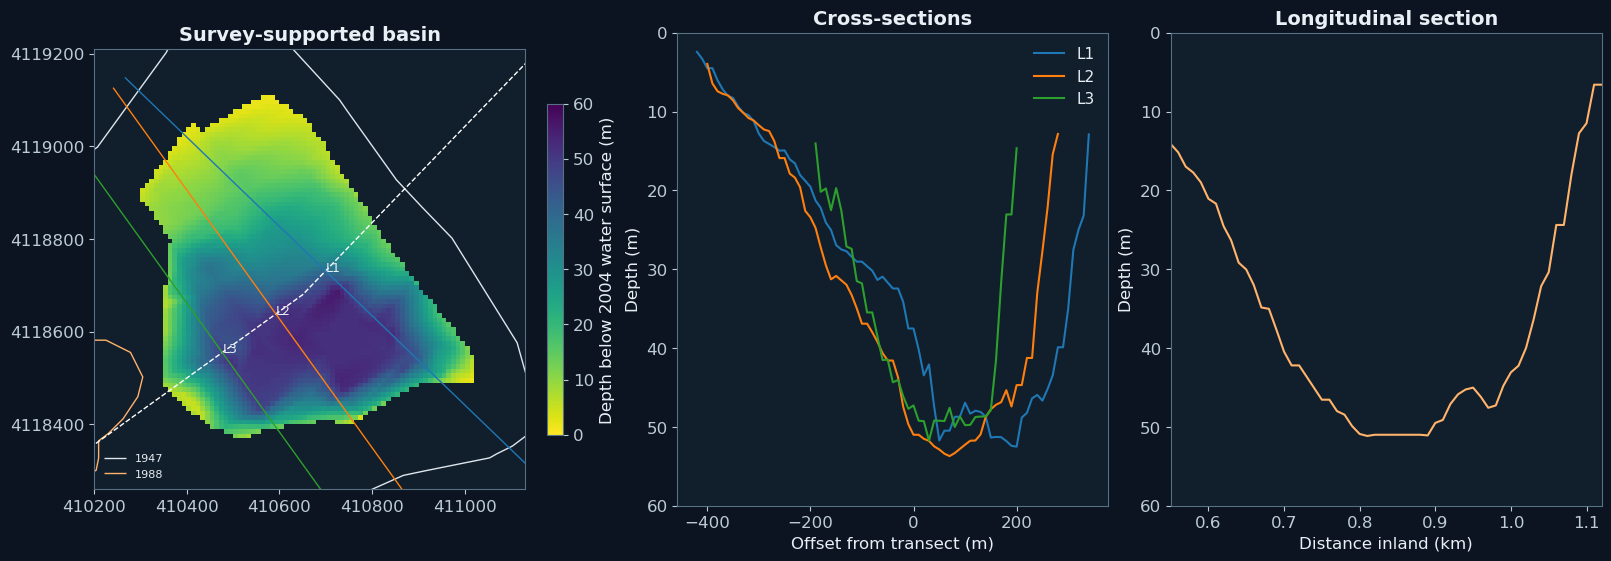

,depth_threshold_m,supported_area_at_least_depth_km2
0,0,0.3301
1,10,0.2836
2,20,0.2145
3,30,0.1519
4,40,0.1006
5,50,0.0474


,year,supported_basin_within_outline_km2,supported_depth_ge_30m_within_outline_km2
0,1947,0.3301,0.1519
1,1988,0.0000,0.0000
2,2014,0.0000,0.0000
3,2019,0.0000,0.0000
4,2026,0.0000,0.0000


,profile,model_cells,bed_bias_m,bed_MAE_m,bed_RMSE_m,geometry_status,use_primary_metrics
0,BG30,2,-61.78,61.78,62.07,registered_archive_section,True
1,BG45,2,-24.89,24.89,25.54,registered_archive_section,True
2,BG50,3,6.29,7.82,10.46,registered_archive_section,True


In [11]:
## Measure the supported lagoon basin and its overlap with historical ice ##

with rasterio.open(bathy_path) as src:
    depth = src.read(1, masked = True).astype(float).filled(np.nan)
    bathy_transform, bathy_bounds, bathy_crs = src.transform, src.bounds, src.crs
    pixel_area = abs(src.transform.a * src.transform.e - src.transform.b * src.transform.d)

supported = np.isfinite(depth) & (depth >= 0)
basin_summary = pd.DataFrame([dict(depth_threshold_m = threshold,
    supported_area_at_least_depth_km2 = np.count_nonzero(
        supported & (depth >= threshold)) * pixel_area / 1e6)
    for threshold in [0, 10, 20, 30, 40, 50]])

overlap_rows = []
for year in years:
    footprint = gpd.GeoSeries([get_outline('Brown', year)],
        crs = extents.crs).to_crs(bathy_crs).iloc[0]
    inside = geometry_mask([footprint], out_shape = depth.shape,
        transform = bathy_transform, invert = True)
    overlap_rows.append(dict(year = year,
        supported_basin_within_outline_km2 = (inside & supported).sum() * pixel_area / 1e6,
        supported_depth_ge_30m_within_outline_km2 = (
            inside & supported & (depth >= 30)).sum() * pixel_area / 1e6))

basin_overlap = pd.DataFrame(overlap_rows)
basin_summary.to_csv(synthesis_dir / 'Brown_supported_basin_depth_areas.csv', index = False)
basin_overlap.to_csv(synthesis_dir / 'Brown_basin_historical_overlap.csv', index = False)

line = transects['Brown']
lagoon_stations = np.arange(0, line.length, 10)
lagoon_xy = transect_xy(line, lagoon_stations, [0])[:, 0]
lagoon_depth, _ = sample_raster(bathy_path, lagoon_xy)
lagoon_profile = pd.DataFrame({'distance_m': lagoon_stations, 'E': lagoon_xy[:, 0],
    'N': lagoon_xy[:, 1], 'depth_m': lagoon_depth})
lagoon_profile['approx_bed_elevation_m'] = settings['assumed_water_level_m'] - lagoon_depth
lagoon_profile.to_csv(synthesis_dir / 'Brown_lagoon_long_profile.csv', index = False)

valid_stations = lagoon_stations[np.isfinite(lagoon_depth)]
if not len(valid_stations):
    raise ValueError('Brown transect misses bathymetric support; adjust its lagoon vertices.')

section_stations = np.quantile(valid_stations, [0.25, 0.5, 0.75])
cross_sections = []
for number, station in enumerate(section_stations, 1):
    offsets = np.arange(-600, 601, 10)
    xy = transect_xy(line, [station], offsets)[0]
    values, _ = sample_raster(bathy_path, xy)
    cross_sections.append(pd.DataFrame({'section': f'L{number}', 'distance_m': station,
        'offset_m': offsets, 'E': xy[:, 0], 'N': xy[:, 1], 'depth_m': values}))

lagoon_cross_sections = pd.concat(cross_sections, ignore_index = True)
lagoon_cross_sections.to_csv(synthesis_dir / 'Brown_lagoon_cross_sections.csv', index = False)

fig, axes = plt.subplots(1, 3, figsize = (16, 5.5), layout = 'constrained')
image = axes[0].imshow(np.ma.masked_invalid(depth), origin = 'upper', cmap = 'viridis_r',
    extent = [bathy_bounds.left, bathy_bounds.right, bathy_bounds.bottom, bathy_bounds.top],
    vmin = 0, vmax = 60)

for year, colour in [(1947, '#DDE6ED'), (1988, '#FFB36B')]:
    extents.loc[extents.name_1.eq('Brown') & extents.year.eq(year)].boundary.plot(
        ax = axes[0], color = colour, linewidth = 1, label = str(year))
axes[0].plot(*line.xy, '--', color = 'white', linewidth = 1)

for label, part in lagoon_cross_sections.groupby('section'):
    axes[0].plot(part.E, part.N, linewidth = 1)
    centre = part.loc[part.offset_m.eq(0)].iloc[0]
    axes[0].text(centre.E, centre.N, label, fontsize = 9)
    axes[1].plot(part.offset_m, part.depth_m, label = label)

axes[0].set(xlim = (bathy_bounds.left - 100, bathy_bounds.right + 100),
    ylim = (bathy_bounds.bottom - 100, bathy_bounds.top + 100),
    title = 'Survey-supported basin', aspect = 'equal')
axes[0].ticklabel_format(style = 'plain', useOffset = False)
axes[0].legend(fontsize = 8)
fig.colorbar(image, ax = axes[0], label = 'Depth below 2004 water surface (m)', shrink = 0.7)

axes[1].set(title = 'Cross-sections', xlabel = 'Offset from transect (m)',
    ylabel = 'Depth (m)', ylim = (60, 0))
axes[1].legend()

axes[2].plot(lagoon_stations / 1000, lagoon_depth, color = colours['Brown'])
axes[2].set(title = 'Longitudinal section', xlabel = 'Distance inland (km)', ylabel = 'Depth (m)',
    xlim = (valid_stations.min() / 1000, valid_stations.max() / 1000), ylim = (60, 0))

save_figure(fig, '05a_Brown_basin_geometry')
display(basin_summary.round(4))
display(basin_overlap.round(4))
display(radar.round(2))

**Results / interpretation — pending:** Describe the supported depression,
its deepest areas, cross-sectional asymmetry and any shallower sections.
Relate historical ice occupation to the basin geometry. Distinguish a
measured depression from a demonstrated overdeepening with a surveyed outlet.

### From lagoon basin to surviving glacier

The lagoon and glacier profiles are shown on a common exploratory elevation
axis while retaining gaps between datasets. Water levels of 0, 2 and 5 m
illustrate the effect of a vertical offset; these are scenarios, not measured
levels or uncertainty bounds.

Primary interpreted radar-bed samples within 100 m of the transect are
projected onto it for context. Their lateral offsets are retained in the
exported table. They are not treated as exact observations on the transect.

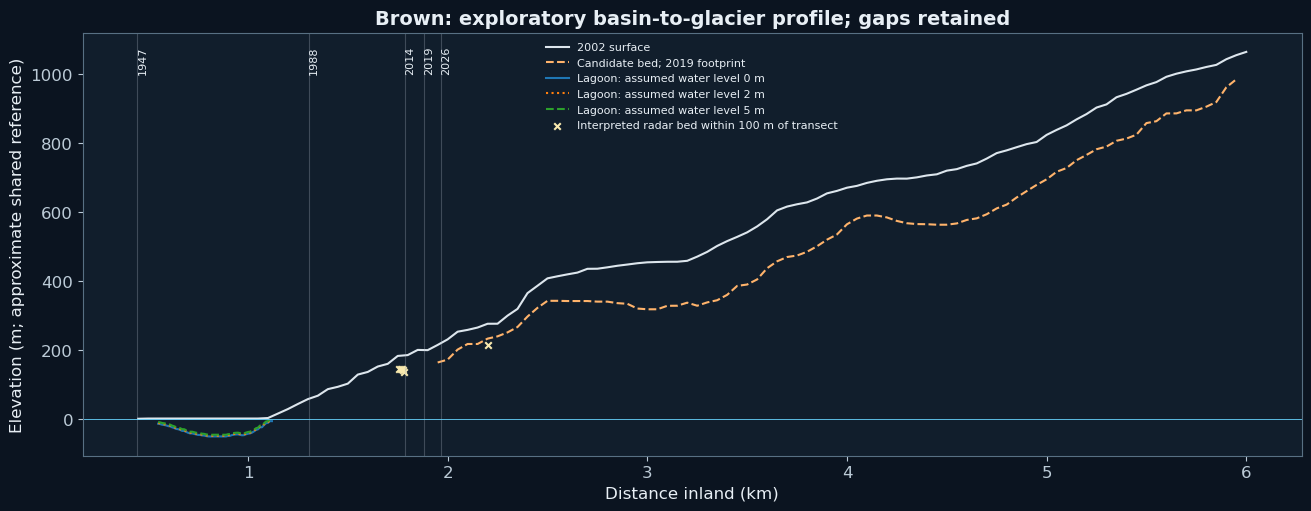

In [12]:
## Compare the lagoon and glacier bed with an explicit water-level assumption ##

p = profiles['Brown']
fig, ax = plt.subplots(figsize = (13, 5), layout = 'constrained')
ax.plot(p.distance_m / 1000, p.surface_m, color = '#DDE6ED', label = '2002 surface')
ax.plot(p.distance_m / 1000, p.bed_smooth_m, '--', color = colours['Brown'],
    label = 'Candidate bed; 2019 footprint')

water_levels = dict.fromkeys([settings['assumed_water_level_m'], 2.0, 5.0])
for water_level, style in zip(water_levels, ['-', ':', '--']):
    ax.plot(lagoon_profile.distance_m / 1000, water_level - lagoon_profile.depth_m,
        style, label = f'Lagoon: assumed water level {water_level:g} m')

radar_projection = pd.read_csv(field_dir / 'Brown_interpreted_bed_samples.csv')
radar_projection = radar_projection.loc[
    radar_projection.use_primary_metrics.astype(str).str.lower().eq('true')].copy()
radar_projection['distance_m'] = [transects['Brown'].project(Point(e, n))
    for e, n in zip(radar_projection.E, radar_projection.N)]
radar_projection['offset_from_transect_m'] = [transects['Brown'].distance(Point(e, n))
    for e, n in zip(radar_projection.E, radar_projection.N)]
radar_projection.to_csv(synthesis_dir / 'Brown_radar_transect_context.csv', index = False)

nearby = radar_projection.loc[radar_projection.offset_from_transect_m <= 100]
if len(nearby):
    ax.scatter(nearby.distance_m / 1000, nearby.bed_asl_m, s = 22, marker = 'x',
        color = '#F8E9AE', label = 'Interpreted radar bed within 100 m of transect')

for row in termini.loc[termini.name_1.eq('Brown')].itertuples():
    if np.isfinite(row.front_distance_m):
        ax.axvline(row.front_distance_m / 1000, color = '#AAB4C3', alpha = 0.3, linewidth = 0.8)
        ax.text(row.front_distance_m / 1000, 0.97, str(row.year), rotation = 90,
            transform = ax.get_xaxis_transform(), va = 'top', fontsize = 8)

ax.axhline(0, color = '#69D5FF', linewidth = 0.6)
ax.set(title = 'Brown: exploratory basin-to-glacier profile; gaps retained',
    xlabel = 'Distance inland (km)', ylabel = 'Elevation (m; approximate shared reference)')
ax.legend(fontsize = 8)
save_figure(fig, '05b_Brown_basin_to_glacier')

**Results / interpretation — pending:** Explain which aspects of the
basin-to-glacier geometry remain apparent under the illustrative water-level
offsets. Identify where unsupported terrain prevents conclusions about sills
or connectivity.

Develop an observation-led account of retreat through the basin and subsequent
withdrawal inland. Separate the mapped sequence from proposed mechanisms
such as calving, subaqueous melting or seawater intrusion, and identify the
measurements needed to test those mechanisms.

## 7. Assemble the comparison and preserve its limits

Export a compact evidence table for the results section and interactive map. Keep modelled thickness explicitly distinguishable from observed retreat and contemporary velocity. Save the main analytical assumptions with the outputs so that later visualisations retain the same interpretation.

In [13]:
## Assemble the final evidence table ##

summary = comparison[[
    "name_1", "median_speed_m_yr", "coverage_percent",
    "lower_third_speed_m_yr", "lower_third_coverage_percent",
    "thickness_median_m", "mean_reported_thickness_error_m"
]].set_index("name_1").reindex(names)

summary = summary.rename(columns = {
    "thickness_median_m": "modelled_thickness_median_m"})

summary["area_loss_1947_2026_percent"] = (
    100 * (1 - area.loc[2026] / area.loc[1947]))

summary["annual_loss_2019_2026_percent"] = (
    retreat.loc[retreat.start_year.eq(2019)]
    .set_index("name_1").annual_loss_percent)

summary["annual_loss_2014_2019_percent"] = (
    retreat.loc[retreat.start_year.eq(2014)]
    .set_index("name_1").annual_loss_percent)

summary["lower_2014_footprint_surface_slope_deg"] = (
    terrain_full.loc[terrain_full.elevation_band.eq("lower")]
    .set_index("name_1").slope_median_deg)

summary['recent_transect_retreat_m_yr'] = transect_retreat.loc[
    transect_retreat.start_year.eq(2019)].set_index('name_1').transect_retreat_m_yr

summary['summer_incidence_2014_footprint'] = exposure.loc[
    exposure.support.eq('2014 footprint')].set_index('name_1').median_summer_incidence

summary['screened_candidate_bed_highs'] = candidates.groupby('name_1').size().reindex(
    summary.index, fill_value = 0)

summary.to_csv(synthesis_dir / 'focus_evidence_summary.csv')

metadata = dict(
    study_glaciers = names,
    outline_years = years,
    primary_comparison = (
        "Descriptive comparison of Brown and Stephenson; "
        "no glacier-population inference"),
    low_elevation_thresholds_m = thresholds,
    low_elevation_cell_run = not low_area_history.empty,
    limitations = [
        "Unequal intervals; annual percentage uses interval-start area",
        "1947 historical outlines include pre-year source records",
        "No advance and unchanged ice above 1000 m are imposed for recent outlines",
        "2002 elevations are fixed; threshold areas are not historical hypsometry or AAR",
        "2014 velocity footprint differs from 2019 model reporting footprint",
        "Pair-level velocity errors are not confidence intervals of the final median",
        "Mapped Snow/Ice does not identify underlying lithology",
        "Radar checks are local; BG35 excluded from primary metrics",
        "2004 lagoon depths use the water surface, not a shared bed-elevation datum"])

(synthesis_dir / "synthesis_metadata.json").write_text(
    json.dumps(metadata, indent = 2), encoding = "utf-8")

display(summary.T.round(2))

name_1,Brown,Stephenson
median_speed_m_yr,207.68,281.75
coverage_percent,64.71,91.51
lower_third_speed_m_yr,39.57,266.52
lower_third_coverage_percent,38.46,85.41
modelled_thickness_median_m,127.02,116.47
mean_reported_thickness_error_m,45.67,44.67
area_loss_1947_2026_percent,40.44,68.49
annual_loss_2019_2026_percent,0.61,0.40
annual_loss_2014_2019_percent,0.42,1.84
lower_2014_footprint_surface_slope_deg,14.90,14.51


In [14]:
## Record the new analyses and their scope ##

analysis_metadata = dict(
    settings = settings,
    transect_vertices_utm43s = transect_vertices,
    transect_scope = 'Brown lower trunk; Stephenson northern surviving tongue and former southern tongue',
    transect_front = 'Seaward end of the line segment connected to the inland endpoint; detached segments excluded',
    bed_scope = 'Candidate bed restricted to 2019 footprint; centreline NoData retained',
    width_scope = 'Connected mapped ice-polygon width, not surveyed bedrock valley width',
    candidate_scope = 'Descriptive screening; persistence counts are not probabilities',
    solar_scope = 'Four representative November–February days; no atmosphere, horizon shading, albedo or melt model',
    water_level_scope = 'Assumed reference; 0, 2 and 5 m examples are scenarios, not confidence bounds',
    chronology = '2002 surface, newer model thickness, 2000 radar, 2004 bathymetry and 2016–2022 velocity',
    dependence = 'Millan thickness uses velocity; model-bed/flow agreement is not independent validation',
    bathy_scope = 'Supported 2004 reconstruction; historical-outline overlap does not reconstruct historical depth')

(synthesis_dir / 'geomorphology_analysis_metadata.json').write_text(
    json.dumps(analysis_metadata, indent = 2), encoding = 'utf-8')

2387

### Results and interpretation

Across 1947–2026, Stephenson lost 68.5% of its mapped area, compared with Brown’s 40.4%. This greater cumulative loss contrasts with Brown’s higher proportional loss during the latest interval. Together with the low-elevation results, this indicates that present retreat rates must be interpreted in relation to how much vulnerable terrain each glacier has already vacated.

Modelled median thickness differs by only about 11 m between the glaciers, whereas mean supplied thickness errors are approximately 45 m and Brown’s radar comparisons reveal substantial local disagreement. These error measures are not confidence intervals for the medians, but they give little basis for treating the modelled thickness contrast as a decisive explanation.

## Results summary

Brown and Stephenson show contrasting retreat histories, with Stephenson experiencing much greater cumulative area loss and particularly rapid contraction during 1988–2014. Brown’s proportional loss exceeds Stephenson’s during 2019–2026, although Stephenson still loses more absolute area.

The strongest geomorphological evidence is the removal of Stephenson’s formerly extensive low-elevation tongue. Its remaining footprint occupies proportionally less low terrain, consistent with a changing setting for retreat and a possible contribution to its recent slowdown. Lagoon observations provide supporting spatial context, but these analyses do not isolate the effects of calving, water-driven melting or changing mass balance.

Geological mapping identifies foreland deposits but leaves underlying lithology largely unresolved. Contemporary velocity adds evidence of contrasting flow, particularly in the lower glacier, although Brown’s limited coverage and supplied errors restrict interpretation. Radar validation similarly limits reliance on modelled bed geometry.

Overall, the results support a geomorphological explanation involving different retreat histories and remaining terrain, while providing insufficient evidence to attribute the contrast to bedrock geology or to demonstrate that Stephenson’s accumulation area now exceeds its ablation area.